In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_score, recall_score, accuracy_score, f1_score

In [2]:
csv_path = "Dataset/dataset_v1.csv"
df = pd.read_csv(csv_path)

if "task_id" in df.columns:
    df = df.drop(columns=["task_id"])

print("\nColumns:", df.columns.tolist())


Columns: ['language', 'model_name', 'true_bug_type', 'true_failure_symptom', 'predicted_bug_type', 'diagnosis_match', 'code_length', 'fix_success']


## Data Cleanup

In [3]:
print(df["predicted_bug_type"].value_counts())

predicted_bug_type
value misuse                                 493
operator misuse                              433
missing logic                                370
unknown                                      290
variable misuse                              186
excess logic                                 139
function misuse                               15
value misuse**                                 6
operator misuse**                              6
excess logic**                                 5
logic error                                    4
variable misuse**                              4
missing logic**                                4
logic misuse                                   2
** value misuse                                2
logic                                          1
variable and function misuse                   1
logical error                                  1
expected behavior                              1
excess logic </h1>                             1
v

In [4]:
df["predicted_bug_type_clean"] = (
    df["predicted_bug_type"]
    .str.strip()
    .str.replace(r"^\*+|\*+$", "", regex=True)   # remove **
)

canonical_map = {
    "value misuse": "value misuse",
    "operator misuse": "operator misuse",
    "missing logic": "missing logic",
    "excess logic": "excess logic",
    "variable misuse": "variable misuse",
    "function misuse": "function misuse",

    "value misuse, missing logic, excess logic": "unknown",
    "no bug": "unknown",
    "expected behavior": "unknown",
    "excess logic </h1>": "unknown",
    "variable and function misuse": "unknown",
    "logical error": "unknown",
    "logic error": "unknown",
    "syntax error": "unknown",
    "logic misuse": "unknown",
    "logic": "unknown",
    "operator misuse and variable misuse": "unknown",
}

def standardize(val):
    norm = re.sub(r"[^\w]+", "", val.lower())
    for k, v in canonical_map.items():
        if re.sub(r"[^\w]+", "", k.lower()) == norm:
            return v

    return val

df["predicted_bug_type_clean"] = df["predicted_bug_type_clean"].apply(standardize)
df["predicted_bug_type"] = df["predicted_bug_type_clean"]
df.drop(columns=["predicted_bug_type_clean"], inplace=True)

# EDA

In [5]:
print(f"Dataset shape: {df.shape}")
print("\nMissing values per column:\n", df.isna().sum())

Dataset shape: (1968, 8)

Missing values per column:
 language                0
model_name              0
true_bug_type           0
true_failure_symptom    0
predicted_bug_type      0
diagnosis_match         0
code_length             0
fix_success             0
dtype: int64


In [6]:
for col in ['language', 'model_name', 'true_bug_type', 'predicted_bug_type']:
    print(f"\n{col} value counts:")
    print(df[col].value_counts())


language value counts:
language
python    492
cpp       492
java      492
js        492
Name: count, dtype: int64

model_name value counts:
model_name
qwen2.5-coder:7b       656
deepseek-coder:6.7b    656
llama3.1:8b            656
Name: count, dtype: int64

true_bug_type value counts:
true_bug_type
value misuse       528
missing logic      396
excess logic       372
operator misuse    300
variable misuse    276
function misuse     96
Name: count, dtype: int64

predicted_bug_type value counts:
predicted_bug_type
value misuse       501
operator misuse    439
missing logic      374
unknown            305
variable misuse    190
excess logic       144
function misuse     15
Name: count, dtype: int64


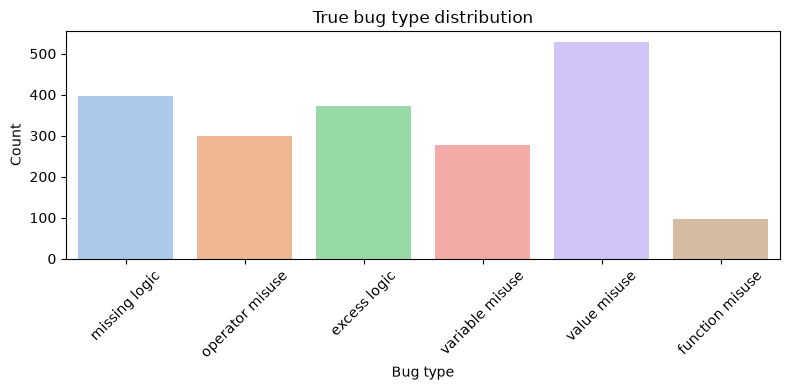

In [7]:
plt.figure(figsize=(8, 4))
sns.countplot(data=df, x="true_bug_type", palette="pastel", hue= "true_bug_type", legend=False)
plt.title("True bug type distribution")
plt.xlabel("Bug type")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

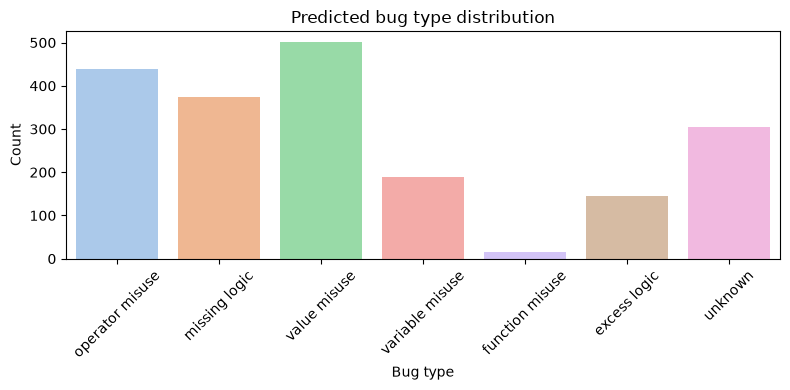

In [8]:
plt.figure(figsize=(8, 4))
sns.countplot(data=df, x="predicted_bug_type", palette="pastel", hue= "predicted_bug_type", legend=False)
plt.title("Predicted bug type distribution")
plt.xlabel("Bug type")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

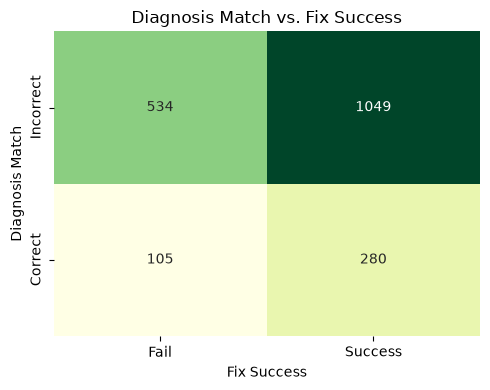

In [9]:
ct = pd.crosstab(df["diagnosis_match"], df["fix_success"])

plt.figure(figsize=(5, 4))

sns.heatmap(
    ct,
    annot=True,
    fmt="d",
    cmap="YlGn",
    cbar=False,
    xticklabels=["Fail", "Success"],
    yticklabels=["Incorrect", "Correct"],
)

plt.title("Diagnosis Match vs. Fix Success")
plt.xlabel("Fix Success")
plt.ylabel("Diagnosis Match")
plt.tight_layout()
plt.show()

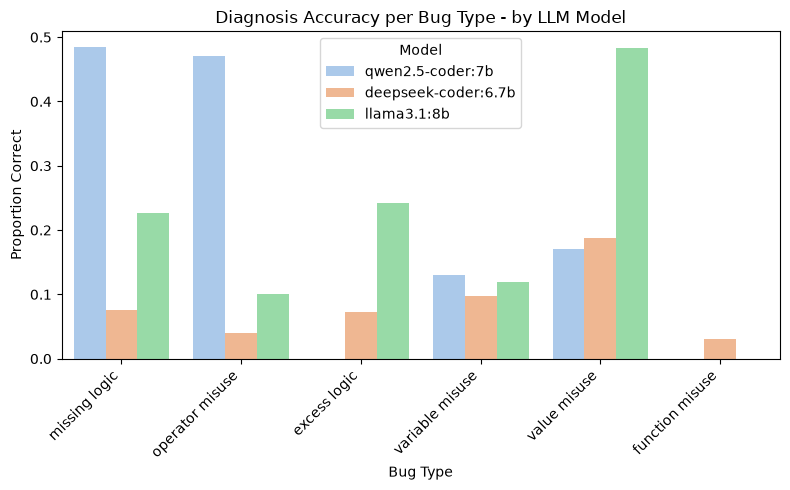

In [10]:
plt.figure(figsize=(8, 5))
sns.barplot(
    data=df,
    x="true_bug_type",
    y="diagnosis_match",
    hue="model_name",
    palette="pastel",
    errorbar=None,
    dodge=True
)
plt.title("Diagnosis Accuracy per Bug Type - by LLM Model")
plt.ylabel("Proportion Correct")
plt.xlabel("Bug Type")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Model")
plt.tight_layout()
plt.show()

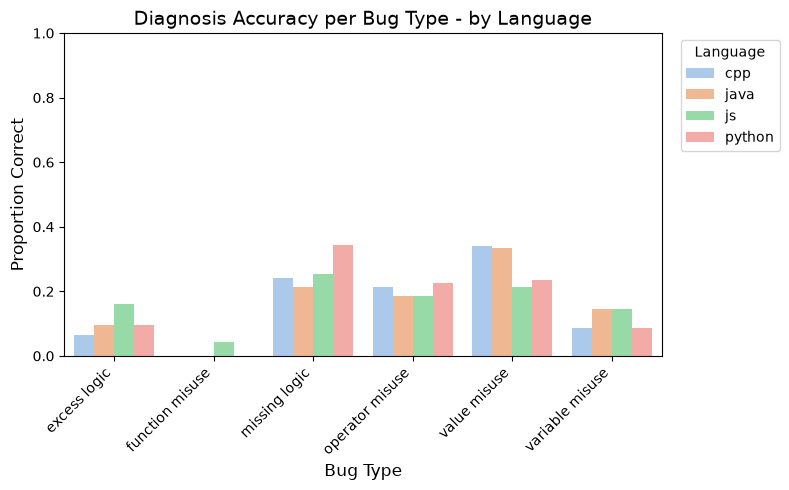

In [11]:
acc_by_lang = df.groupby(["language", "true_bug_type"])["diagnosis_match"].mean().unstack()

plt.figure(figsize=(8, 5))
sns.barplot(
    data=acc_by_lang.reset_index().melt(id_vars="language",
                                        var_name="bug_type",
                                        value_name="accuracy"),
    x="bug_type",
    y="accuracy",
    hue="language",
    palette="pastel"
)

plt.title("Diagnosis Accuracy per Bug Type - by Language", fontsize=14)
plt.ylabel("Proportion Correct", fontsize=12)
plt.xlabel("Bug Type", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.ylim(0, 1)
plt.legend(title="Language", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

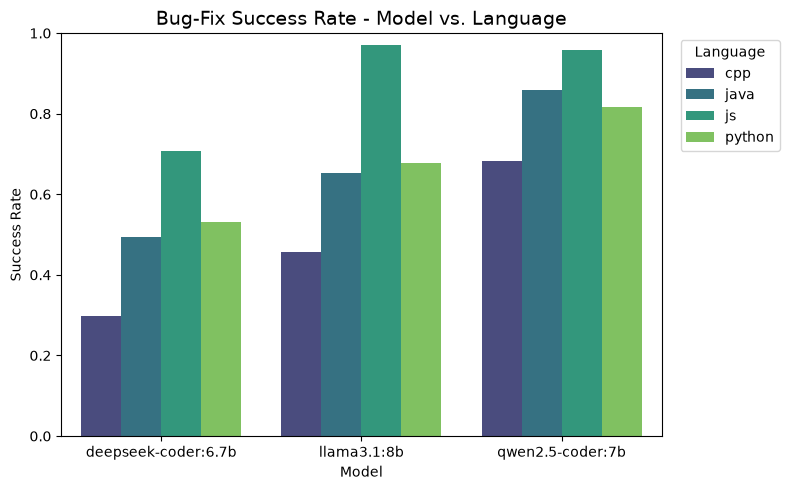

In [12]:
success_by_model_lang = df.groupby(["model_name", "language"])["fix_success"].mean().reset_index().rename(columns={"fix_success": "success_rate"})
success_by_model_lang["success_rate"] = success_by_model_lang["success_rate"].round(3)

plt.figure(figsize=(8, 5))
sns.barplot(
    data=success_by_model_lang,
    x="model_name",
    y="success_rate",
    hue="language",
    palette="viridis",
    dodge=True
)

plt.title("Bug-Fix Success Rate - Model vs. Language", fontsize=14)
plt.xlabel("Model")
plt.ylabel("Success Rate")
plt.ylim(0, 1)
plt.legend(title="Language", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

### Model Setup

In [13]:
cat_cols = df.select_dtypes(include=["object", "str"]).columns.tolist()
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)
print(f"Encoded shape: {df_encoded.shape}")

Encoded shape: (1968, 21)
